In [1]:
!pip install sqlalchemy fastapi uvicorn pandas

In [2]:
from sqlalchemy import create_engine, Column, Integer, String, Float
from sqlalchemy.orm import declarative_base, sessionmaker

DATABASE_URL = "sqlite:///students.db"

engine = create_engine(DATABASE_URL, echo=False)
SessionLocal = sessionmaker(bind=engine)
Base = declarative_base()

In [3]:
class Student(Base):
    __tablename__ = "students"

    id = Column(Integer, primary_key=True, index=True)
    last_name = Column(String, nullable=False)
    first_name = Column(String, nullable=False)
    faculty = Column(String, nullable=False, index=True)
    course = Column(String, nullable=False, index=True)
    grade = Column(Float, nullable=False)

    def __repr__(self):
        return f"Student(id={self.id}, name='{self.last_name} {self.first_name}', faculty='{self.faculty}', course='{self.course}', grade={self.grade})"

In [4]:
Base.metadata.create_all(bind=engine)

In [5]:
import pandas as pd
from sqlalchemy import distinct, func

class StudentDB:
    def __init__(self, session_factory):
        self.session_factory = session_factory

    def add_student(self, last_name: str, first_name: str, faculty: str, course: str, grade: float):
        with self.session_factory() as session:
            student = Student(
                last_name=last_name,
                first_name=first_name,
                faculty=faculty,
                course=course,
                grade=grade
            )
            session.add(student)
            session.commit()
            session.refresh(student)
            return student

    def get_all_students(self):
        with self.session_factory() as session:
            return session.query(Student).all()

    def get_student_by_id(self, student_id: int):
        with self.session_factory() as session:
            return session.query(Student).filter(Student.id == student_id).first()

    def update_student(self, student_id: int, **kwargs):
        with self.session_factory() as session:
            student = session.query(Student).filter(Student.id == student_id).first()
            if not student:
                return None

            allowed_fields = {"last_name", "first_name", "faculty", "course", "grade"}
            for key, value in kwargs.items():
                if key in allowed_fields and value is not None:
                    setattr(student, key, value)

            session.commit()
            session.refresh(student)
            return student

    def delete_student(self, student_id: int):
        with self.session_factory() as session:
            student = session.query(Student).filter(Student.id == student_id).first()
            if not student:
                return False

            session.delete(student)
            session.commit()
            return True

    def load_from_csv(self, csv_path: str):
        df = pd.read_csv(csv_path)

        rename_map = {
            "Фамилия": "last_name",
            "Имя": "first_name",
            "Факультет": "faculty",
            "Курс": "course",
            "Оценка": "grade"
        }
        df = df.rename(columns=rename_map)

        required_columns = {"last_name", "first_name", "faculty", "course", "grade"}
        if not required_columns.issubset(df.columns):
            raise ValueError(f"В CSV должны быть колонки: {required_columns}")

        with self.session_factory() as session:
            students = [
                Student(
                    last_name=row["last_name"],
                    first_name=row["first_name"],
                    faculty=row["faculty"],
                    course=row["course"],
                    grade=float(row["grade"])
                )
                for _, row in df.iterrows()
            ]
            session.bulk_save_objects(students)
            session.commit()

        return len(df)

    def get_students_by_faculty(self, faculty_name: str):
        with self.session_factory() as session:
            return session.query(Student).filter(Student.faculty == faculty_name).all()

    def get_unique_courses(self):
        with self.session_factory() as session:
            result = session.query(distinct(Student.course)).all()
            return [row[0] for row in result]

    def get_students_by_course_below_30(self, course_name: str):
        with self.session_factory() as session:
            return (
                session.query(Student)
                .filter(Student.course == course_name, Student.grade < 30)
                .all()
            )

    def get_average_grade_by_faculty(self, faculty_name: str):
        with self.session_factory() as session:
            avg_grade = (
                session.query(func.avg(Student.grade))
                .filter(Student.faculty == faculty_name)
                .scalar()
            )
            return round(avg_grade, 2) if avg_grade is not None else None

In [6]:
db = StudentDB(SessionLocal)

In [7]:
Base.metadata.drop_all(bind=engine)
Base.metadata.create_all(bind=engine)
db = StudentDB(SessionLocal)

In [8]:
loaded_count = db.load_from_csv("students.csv")
print(f"Загружено записей: {loaded_count}")

Загружено записей: 215


In [9]:
#проверка crud
new_student = db.add_student(
    last_name="Сидоров",
    first_name="Илья",
    faculty="ФИТ",
    course="Базы данных",
    grade=75
)
print(new_student)

Student(id=216, name='Сидоров Илья', faculty='ФИТ', course='Базы данных', grade=75.0)


In [10]:
students = db.get_all_students()
students[:5]

[Student(id=1, name='Ли Иван', faculty='АВТФ', course='Теор. Механика', grade=52.0),
 Student(id=2, name='Ким Петр', faculty='ФПМИ', course='Мат. Анализ', grade=28.0),
 Student(id=3, name='Райт Вероника', faculty='ФЛА', course='Теор. Механика', grade=7.0),
 Student(id=4, name='Джонс Андрей', faculty='РЭФ', course='Мат. Анализ', grade=4.0),
 Student(id=5, name='Джонс Андрей', faculty='РЭФ', course='Информатика', grade=40.0)]

In [11]:
updated = db.update_student(new_student.id, grade=82, faculty="ФПМИ")
print(updated)

Student(id=216, name='Сидоров Илья', faculty='ФПМИ', course='Базы данных', grade=82.0)


In [12]:
result = db.delete_student(new_student.id)
print("Удаление выполнено:", result)

Удаление выполнено: True


In [13]:
faculty_students = db.get_students_by_faculty("ФПМИ")
faculty_students[:10]

[Student(id=2, name='Ким Петр', faculty='ФПМИ', course='Мат. Анализ', grade=28.0),
 Student(id=16, name='Смит Федор', faculty='ФПМИ', course='Мат. Анализ', grade=51.0),
 Student(id=17, name='Смит Федор', faculty='ФПМИ', course='Физика', grade=95.0),
 Student(id=18, name='Смит Федор', faculty='ФПМИ', course='Информатика', grade=3.0),
 Student(id=19, name='Смит Федор', faculty='ФПМИ', course='История', grade=93.0),
 Student(id=49, name='Райт Вероника', faculty='ФПМИ', course='Теор. Механика', grade=0.0),
 Student(id=50, name='Райт Вероника', faculty='ФПМИ', course='Мат. Анализ', grade=47.0),
 Student(id=51, name='Райт Вероника', faculty='ФПМИ', course='История', grade=11.0),
 Student(id=52, name='Райт Вероника', faculty='ФПМИ', course='Психология', grade=68.0),
 Student(id=79, name='Джонс Андрей', faculty='ФПМИ', course='Физика', grade=31.0)]

In [14]:
unique_courses = db.get_unique_courses()
unique_courses

['Информатика',
 'История',
 'Мат. Анализ',
 'Психология',
 'Теор. Механика',
 'Физика']

In [15]:
bad_students = db.get_students_by_course_below_30("Мат. Анализ")
bad_students

[Student(id=2, name='Ким Петр', faculty='ФПМИ', course='Мат. Анализ', grade=28.0),
 Student(id=4, name='Джонс Андрей', faculty='РЭФ', course='Мат. Анализ', grade=4.0),
 Student(id=29, name='Ким Петр', faculty='ФТФ', course='Мат. Анализ', grade=2.0),
 Student(id=69, name='Браун Николай', faculty='ФЛА', course='Мат. Анализ', grade=27.0),
 Student(id=88, name='Чжоу Мария', faculty='ФПМИ', course='Мат. Анализ', grade=13.0),
 Student(id=96, name='Тан Екатеринар', faculty='ФПМИ', course='Мат. Анализ', grade=7.0),
 Student(id=127, name='Ким Петр', faculty='ФЛА', course='Мат. Анализ', grade=12.0),
 Student(id=135, name='Смит Федор', faculty='ФЛА', course='Мат. Анализ', grade=29.0),
 Student(id=143, name='Тан Екатеринар', faculty='ФТФ', course='Мат. Анализ', grade=15.0),
 Student(id=158, name='Ву Дмитрий', faculty='РЭФ', course='Мат. Анализ', grade=3.0),
 Student(id=171, name='Ким Петр', faculty='РЭФ', course='Мат. Анализ', grade=17.0),
 Student(id=191, name='Ли Иван', faculty='ФЛА', course='Ма

In [16]:
avg_grade = db.get_average_grade_by_faculty("ФПМИ")
print("Средний балл по факультету ФПМИ:", avg_grade)

Средний балл по факультету ФПМИ: 49.23


In [17]:
#fastapi
from fastapi import FastAPI, HTTPException
from pydantic import BaseModel
from typing import Optional, List

In [18]:
class StudentCreate(BaseModel):
    last_name: str
    first_name: str
    faculty: str
    course: str
    grade: float

class StudentUpdate(BaseModel):
    last_name: Optional[str] = None
    first_name: Optional[str] = None
    faculty: Optional[str] = None
    course: Optional[str] = None
    grade: Optional[float] = None

class StudentResponse(BaseModel):
    id: int
    last_name: str
    first_name: str
    faculty: str
    course: str
    grade: float

    class Config:
        from_attributes = True

C:\Users\user\AppData\Local\Temp\ipykernel_12532\3667104114.py:15: PydanticDeprecatedSince20: Support for class-based `config` is deprecated, use ConfigDict instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  class StudentResponse(BaseModel):


In [19]:
app = FastAPI(title="Students API")
db = StudentDB(SessionLocal)

In [20]:
@app.post("/students", response_model=StudentResponse)
def create_student(student: StudentCreate):
    return db.add_student(
        last_name=student.last_name,
        first_name=student.first_name,
        faculty=student.faculty,
        course=student.course,
        grade=student.grade
    )

@app.get("/students", response_model=List[StudentResponse])
def read_students():
    return db.get_all_students()

@app.get("/students/{student_id}", response_model=StudentResponse)
def read_student(student_id: int):
    student = db.get_student_by_id(student_id)
    if not student:
        raise HTTPException(status_code=404, detail="Студент не найден")
    return student

@app.put("/students/{student_id}", response_model=StudentResponse)
def update_student(student_id: int, student_data: StudentUpdate):
    updated_student = db.update_student(student_id, **student_data.model_dump(exclude_none=True))
    if not updated_student:
        raise HTTPException(status_code=404, detail="Студент не найден")
    return updated_student

@app.delete("/students/{student_id}")
def delete_student(student_id: int):
    success = db.delete_student(student_id)
    if not success:
        raise HTTPException(status_code=404, detail="Студент не найден")
    return {"message": "Студент удалён"}

In [21]:
@app.get("/students/faculty/{faculty_name}", response_model=List[StudentResponse])
def students_by_faculty(faculty_name: str):
    return db.get_students_by_faculty(faculty_name)

@app.get("/courses")
def unique_courses():
    return {"courses": db.get_unique_courses()}

@app.get("/students/course/{course_name}/below-30", response_model=List[StudentResponse])
def students_by_course_below_30(course_name: str):
    return db.get_students_by_course_below_30(course_name)

@app.get("/faculties/{faculty_name}/average-grade")
def average_grade_by_faculty(faculty_name: str):
    avg = db.get_average_grade_by_faculty(faculty_name)
    if avg is None:
        raise HTTPException(status_code=404, detail="Факультет не найден")
    return {"faculty": faculty_name, "average_grade": avg}

In [23]:
#http://127.0.0.1:8001/docs свагер

In [32]:
!python -m uvicorn my_api:app --host 127.0.0.1 --port 8001

APP STARTED


INFO:     Started server process [17860]
INFO:     Waiting for application startup.
INFO:     Application startup complete.
ERROR:    [Errno 10048] error while attempting to bind on address ('127.0.0.1', 8001): обычно разрешается только одно использование адреса сокета (протокол/сетевой адрес/порт)
INFO:     Waiting for application shutdown.
INFO:     Application shutdown complete.


In [33]:
!python -m uvicorn my_api:app --reload --port 8001

^C


In [34]:
!python -m uvicorn my_api:app --reload --port 8002
#http://127.0.0.1:8002/docs

^C


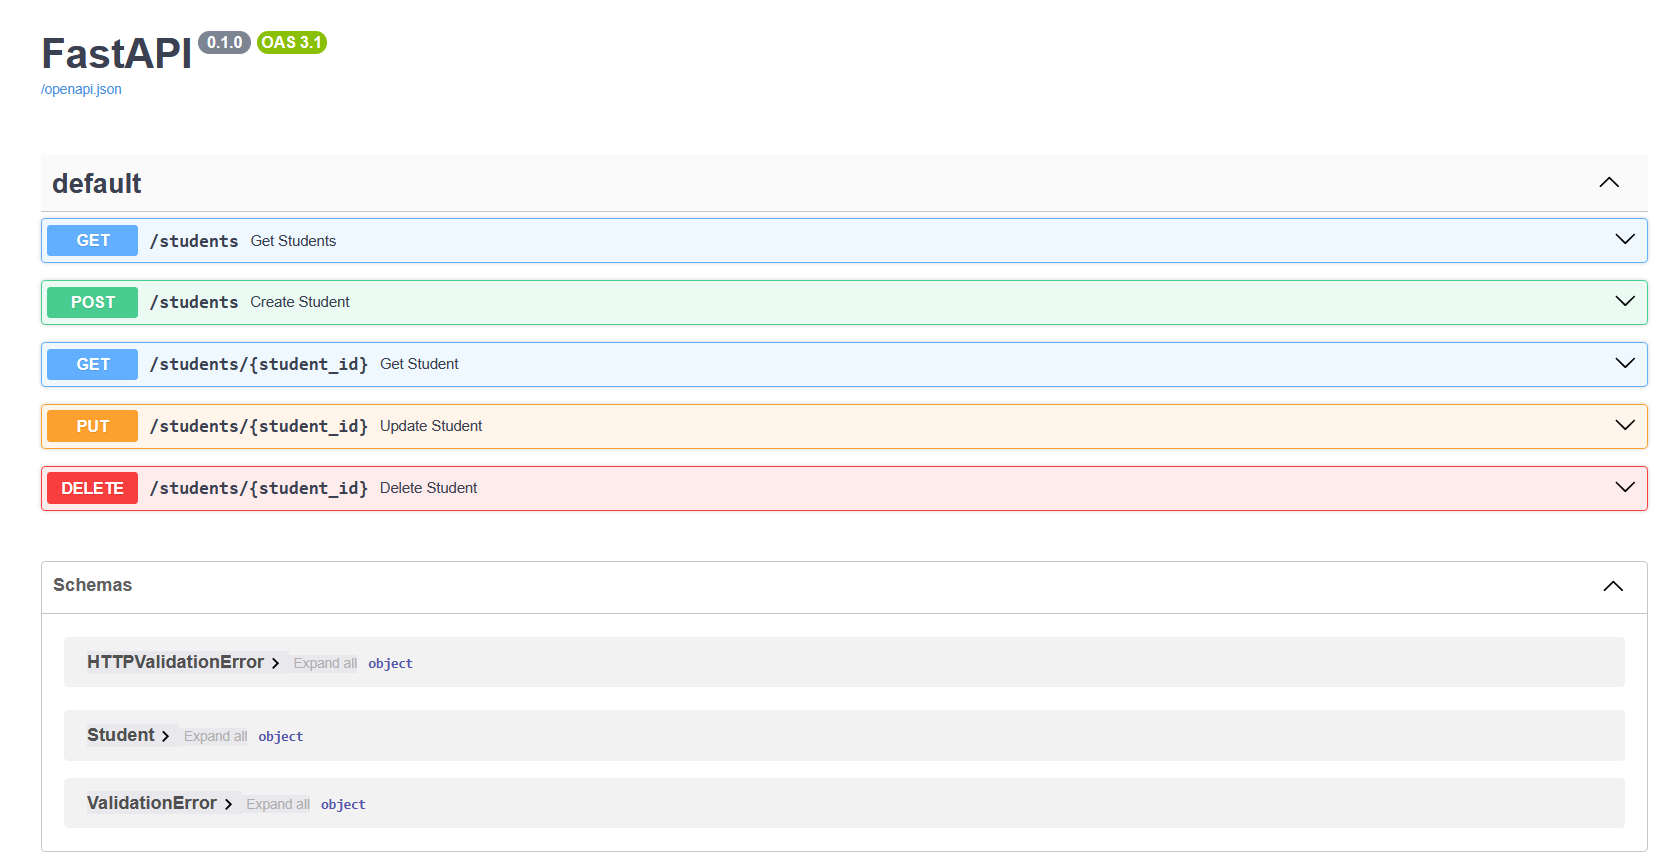